## Setup: Import Libraries and Load Data


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from pathlib import Path


In [15]:
# Configure visualization settings
plt.style.use('default')
sns.set_theme(style='darkgrid', palette='husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully")

Libraries imported successfully


In [16]:
# Load the merged master dataset
DATA_PATH = Path('../../data/merged/merged.csv')
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)

Dataset loaded: (32548, 23)

Column names and types:
code_module                       str
code_presentation                 str
id_student                      int64
gender                            str
region                            str
highest_education                 str
imd_band                          str
age_band                          str
num_of_prev_attempts            int64
studied_credits                 int64
disability                        str
final_result                      str
date_registration             float64
total_clicks                  float64
avg_clicks_per_day            float64
num_sites                     float64
num_unique_sites              float64
module_presentation_length      int64
total_unique_activities         int64
tma_cma_weighted_score        float64
total_submissions             float64
late_submissions_count        float64
avg_submission_delay          float64
dtype: object


In [17]:
# Basic dataset information
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nShape: {df.shape}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nTarget variable (final_result) distribution:")
print(df['final_result'].value_counts())

DATASET OVERVIEW

Shape: (32548, 23)

Missing values:
code_module                   0
code_presentation             0
id_student                    0
gender                        0
region                        0
highest_education             0
imd_band                      0
age_band                      0
num_of_prev_attempts          0
studied_credits               0
disability                    0
final_result                  0
date_registration             0
total_clicks                  0
avg_clicks_per_day            0
num_sites                     0
num_unique_sites              0
module_presentation_length    0
total_unique_activities       0
tma_cma_weighted_score        0
total_submissions             0
late_submissions_count        0
avg_submission_delay          0
dtype: int64

Target variable (final_result) distribution:
final_result
Pass           12360
Withdrawn      10117
Fail            7047
Distinction     3024
Name: count, dtype: int64


## 0. Remove features before analysis


Remove id_student as it has no relation to the final_result


In [18]:
if 'id_student' in df.columns:
    df.drop(columns=['id_student'], inplace=True)
    print("\nDropped 'id_student' column as no relation to analysis.")


Dropped 'id_student' column as no relation to analysis.


Remove region, as it is assumed to be related to imd_band.

- Missing values of imd_band where imputed using region


In [19]:
if 'region' in df.columns:
    df.drop(columns=['region'], inplace=True)
    print("\nDropped 'region' column will not provide new information for final_result prediction.")


Dropped 'region' column will not provide new information for final_result prediction.


## 1. Correlation Matrix Analysis

Identify numeric features and their correlation with target variables (final_result, is_withdrawn). Features with near-zero correlation may have limited predictive power.


In [20]:
# Higher values = Academic Success
success_mapping = {
    'Distinction': 3, 
    'Pass': 2, 
    'Fail': 1, 
    'Withdrawn': 0
}

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}):")
print(numeric_cols)

# Prepare data for correlation analysis
df_numeric = df[numeric_cols].copy()

# Apply the manual mapping to 'final_result'
# We use .map() to ensure our specific numbers are used
df_numeric['final_result'] = df['final_result'].map(success_mapping).astype(float)
print(f"\nTarget variable after mapping: {df_numeric['final_result'].unique()}")

# Ensure all columns are numeric
df_numeric = df_numeric.astype(float)
print(f"\nDataframe for correlation (including target): {df_numeric.shape}")
print(f"Data types: {df_numeric.dtypes.unique()}")

Numeric columns (13):
['num_of_prev_attempts', 'studied_credits', 'date_registration', 'total_clicks', 'avg_clicks_per_day', 'num_sites', 'num_unique_sites', 'module_presentation_length', 'total_unique_activities', 'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count', 'avg_submission_delay']

Target variable after mapping: [2. 0. 1. 3.]

Dataframe for correlation (including target): (32548, 14)
Data types: [dtype('float64')]


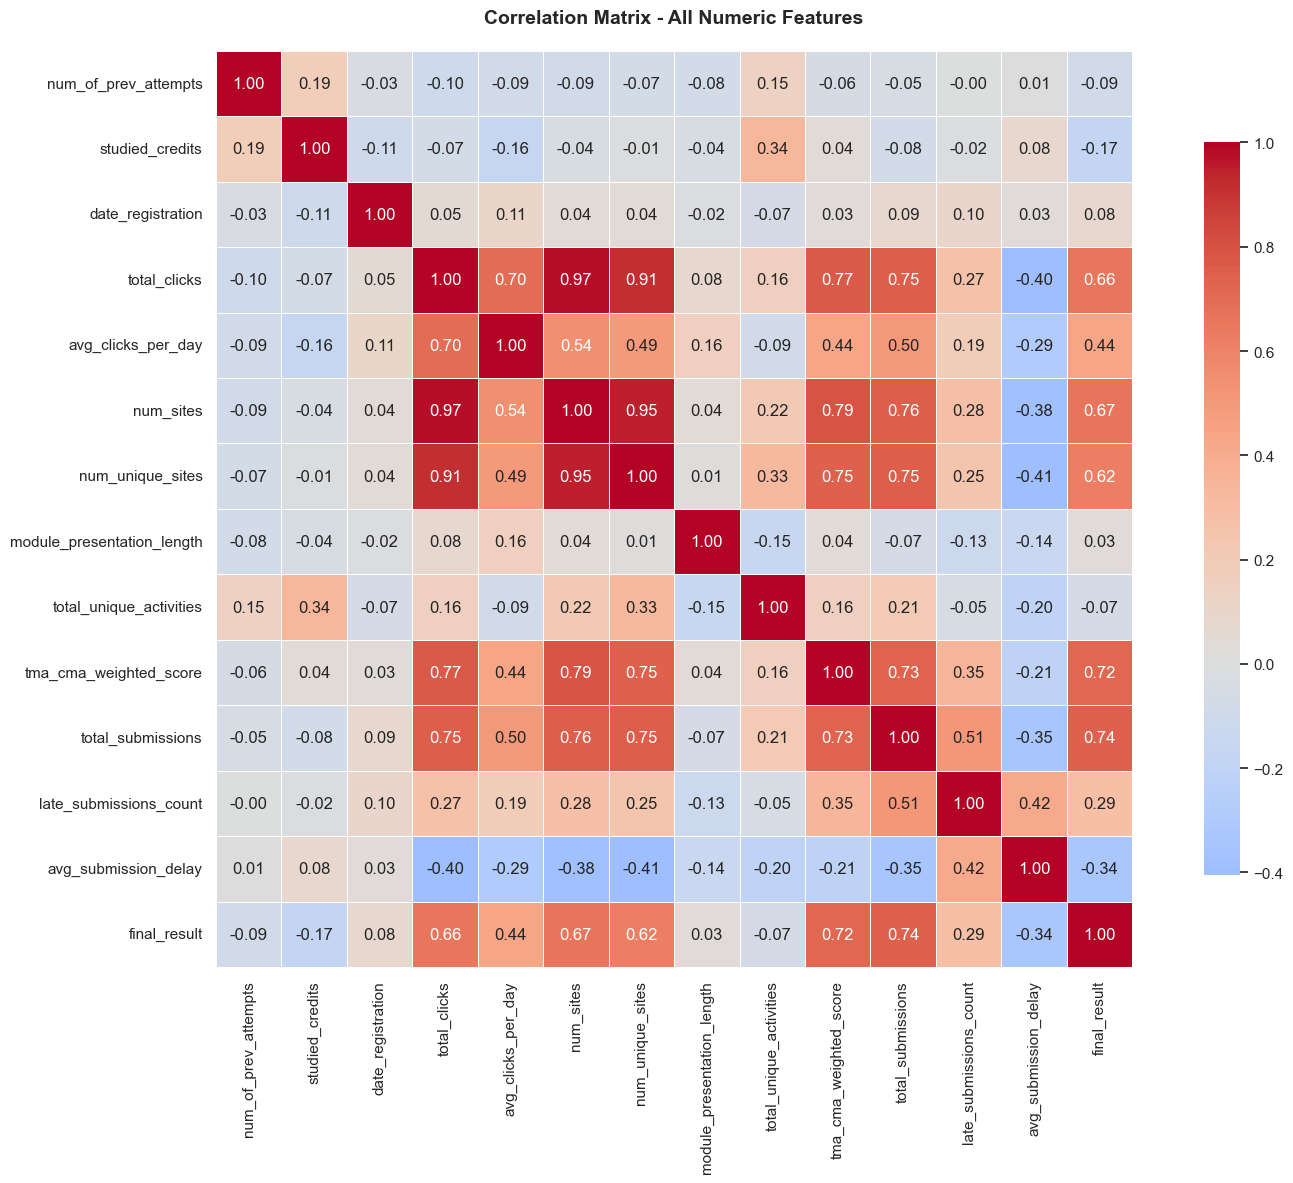

Heatmap generated successfully


In [21]:
# Calculate correlation matrix
correlation_matrix = df_numeric.corr(method='spearman')

# Create heatmap
fig, axes = plt.subplots(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=axes
)
plt.title('Correlation Matrix - All Numeric Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Heatmap generated successfully")

## 2. Mutual Information Gain


Information gain including categorical columns


In [22]:
# 1. Create a copy for MI analysis so we don't mess up the original df
df_mi = df.copy()

# 2. Identify categorical columns that need encoding
categorical_cols = df_mi.select_dtypes(include=['object', 'string']).columns

# 3. Use LabelEncoder to turn strings into numbers
le = LabelEncoder()
for col in categorical_cols:
    df_mi[col] = le.fit_transform(df_mi[col].astype(str))

# 4. Define features (X) and targets (y)
# Ensure we drop the columns that act as 'answers' or are irrelevant
X = df_mi.drop(columns=['final_result'])
y_final = df_mi['final_result']

# 5. Run Mutual Information for Classification
# discrete_features=True tells the model these are categories
mi_scores = mutual_info_classif(X, y_final, discrete_features=True, random_state=42)

# 6. Organize and Display
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("="*40)
print("MUTUAL INFORMATION SCORES (Target: final_result)")
print(mi_results)

MUTUAL INFORMATION SCORES (Target: final_result)
avg_clicks_per_day            1.029846
tma_cma_weighted_score        0.690818
total_clicks                  0.507227
avg_submission_delay          0.454495
total_submissions             0.443139
num_sites                     0.358460
num_unique_sites              0.284679
late_submissions_count        0.078429
total_unique_activities       0.028746
date_registration             0.026083
code_module                   0.023024
studied_credits               0.022931
highest_education             0.015300
num_of_prev_attempts          0.008300
imd_band                      0.007937
module_presentation_length    0.007824
code_presentation             0.006255
age_band                      0.003315
disability                    0.002134
gender                        0.000251
dtype: float64


c:\Users\Dell\Documents\MSc AAI\FAIDM - WM9QG\Group Assessment\data-mining\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\Users\Dell\Documents\MSc AAI\FAIDM - WM9QG\Group Assessment\data-mining\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\Users\Dell\Documents\MSc AAI\FAIDM - WM9QG\Group Assessment\data-mining\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)


## 3. Distribution & Outlier Analysis

Create boxplots for key numeric features grouped by final_result to identify outliers and determine appropriate scaling strategy (RobustScaler for outliers vs StandardScaler).


In [72]:
# Get all numeric features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove unwanted columns
features_to_analyze = [col for col in numeric_features if col not in ['id_student', 'is_withdrawn', 'date_unregistration']]

# Print describe for the rest
print(f"Features to analyze ({len(features_to_analyze)}):")
print(features_to_analyze)
print(f"\nBasic statistics for key features:")
print(df[features_to_analyze].describe())

Features to analyze (11):
['num_of_prev_attempts', 'studied_credits', 'date_registration', 'total_clicks', 'num_sites', 'module_presentation_length', 'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count', 'avg_submission_delay', 'engagement_intensity']

Basic statistics for key features:
       num_of_prev_attempts  studied_credits  date_registration  total_clicks  \
count          32548.000000     32548.000000       32548.000000  32548.000000   
mean               0.163144        79.714422         -69.411300   1216.755285   
std                0.479452        41.046179          49.260522   1693.205934   
min                0.000000        30.000000        -322.000000      0.000000   
25%                0.000000        60.000000        -100.000000    144.000000   
50%                0.000000        60.000000         -57.000000    603.000000   
75%                0.000000       120.000000         -29.000000   1587.000000   
max                6.000000       655.000000 

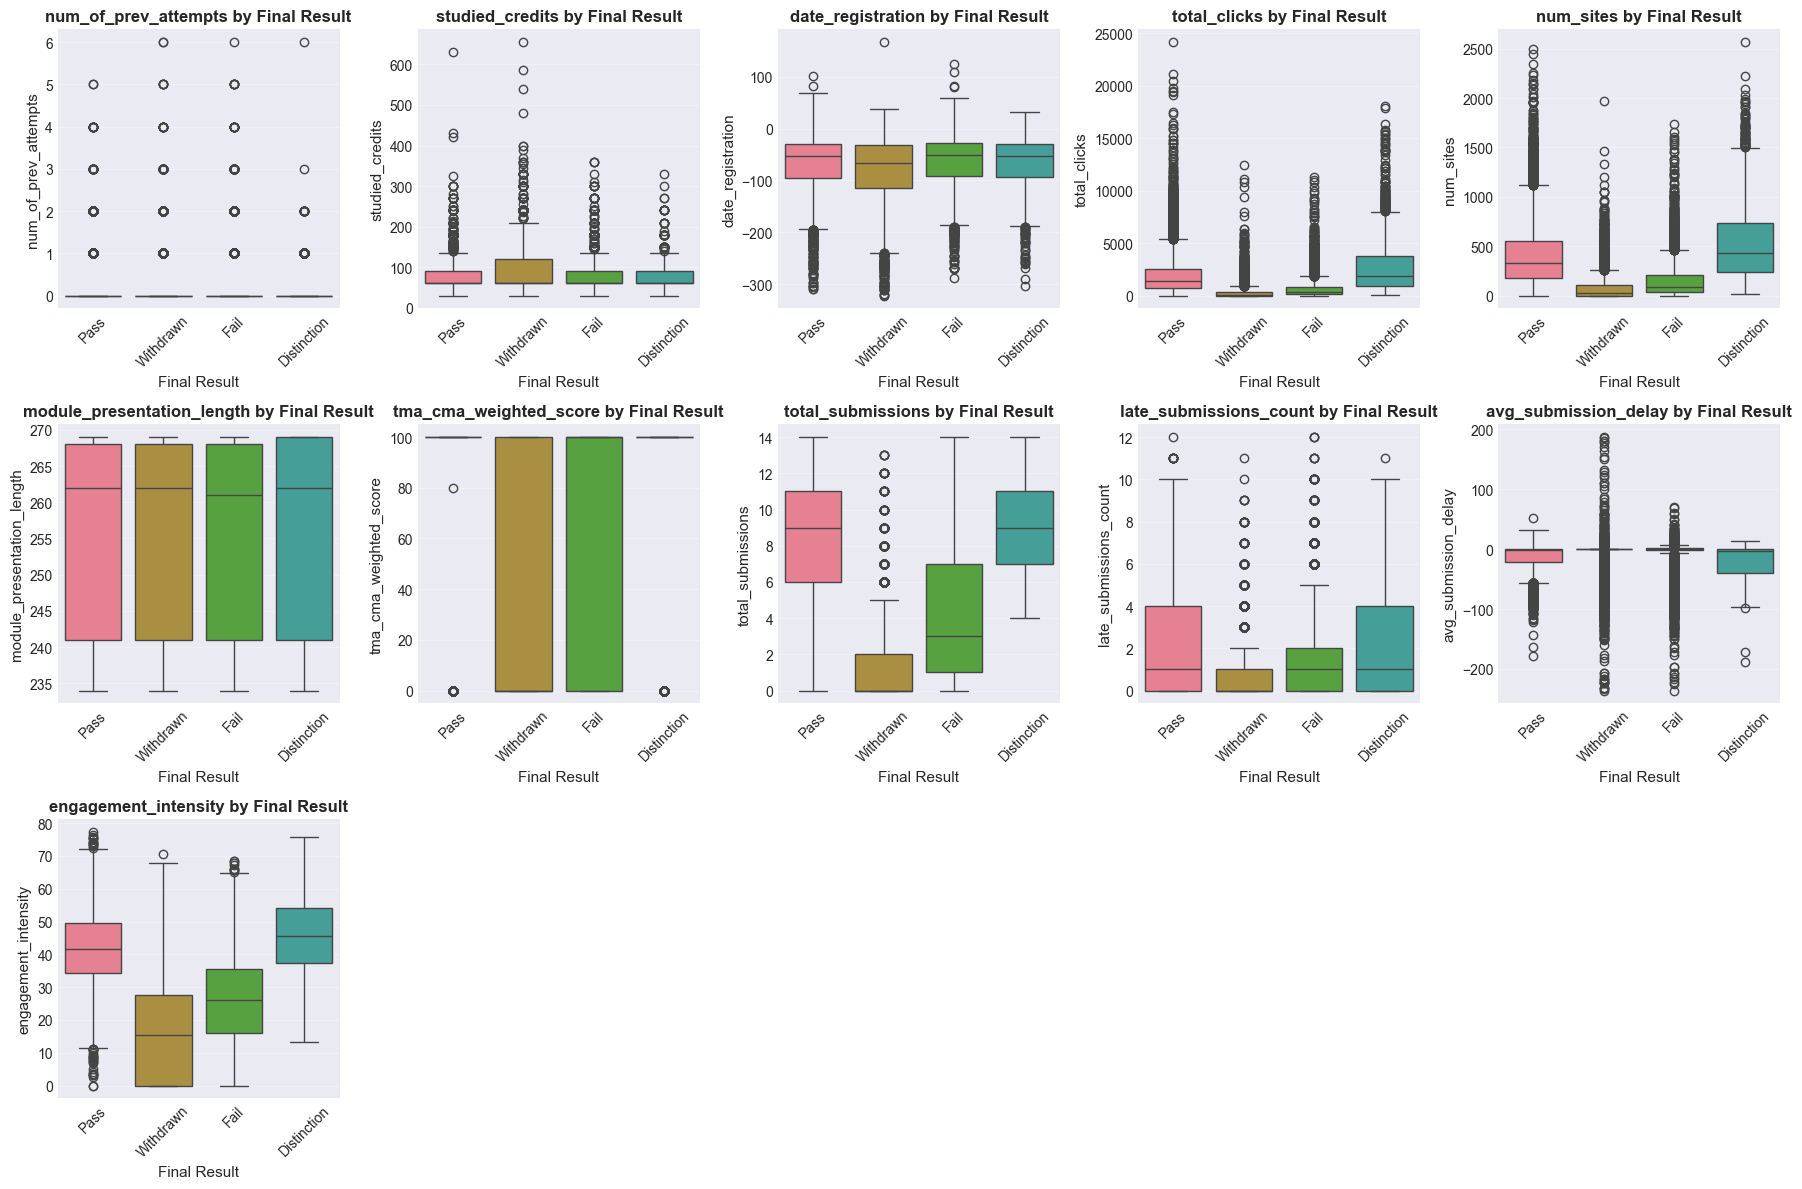

In [73]:
# Create boxplots grouped by final_result
# Calculate grid dimensions dynamically based on number of features
n_features = len(features_to_analyze)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols  # Ceiling division
figsize_height = max(10, n_rows * 4)  # Scale height based on rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, figsize_height))

# The Magic Fix: Flatten the 2D array into 1D
axes_flat = axes.flatten()

for idx, feature in enumerate(features_to_analyze):
    sns.boxplot(
        data=df,
        x='final_result',
        y=feature,
        ax=axes_flat[idx], # Pass the flattened index
        hue='final_result',
        legend=False
    )
    axes_flat[idx].set_title(f'{feature} by Final Result', fontsize=12, fontweight='bold')
    axes_flat[idx].set_xlabel('Final Result', fontsize=11)
    axes_flat[idx].set_ylabel(feature, fontsize=11)
    axes_flat[idx].grid(axis='y', alpha=0.3)
    
    # Rotate x labels for better readability
    axes_flat[idx].tick_params(axis='x', rotation=45)

# Clean up any empty subplots if features_present < 4
for i in range(len(features_to_analyze), len(axes_flat)):
    fig.delaxes(axes_flat[i])

plt.tight_layout()
plt.show()

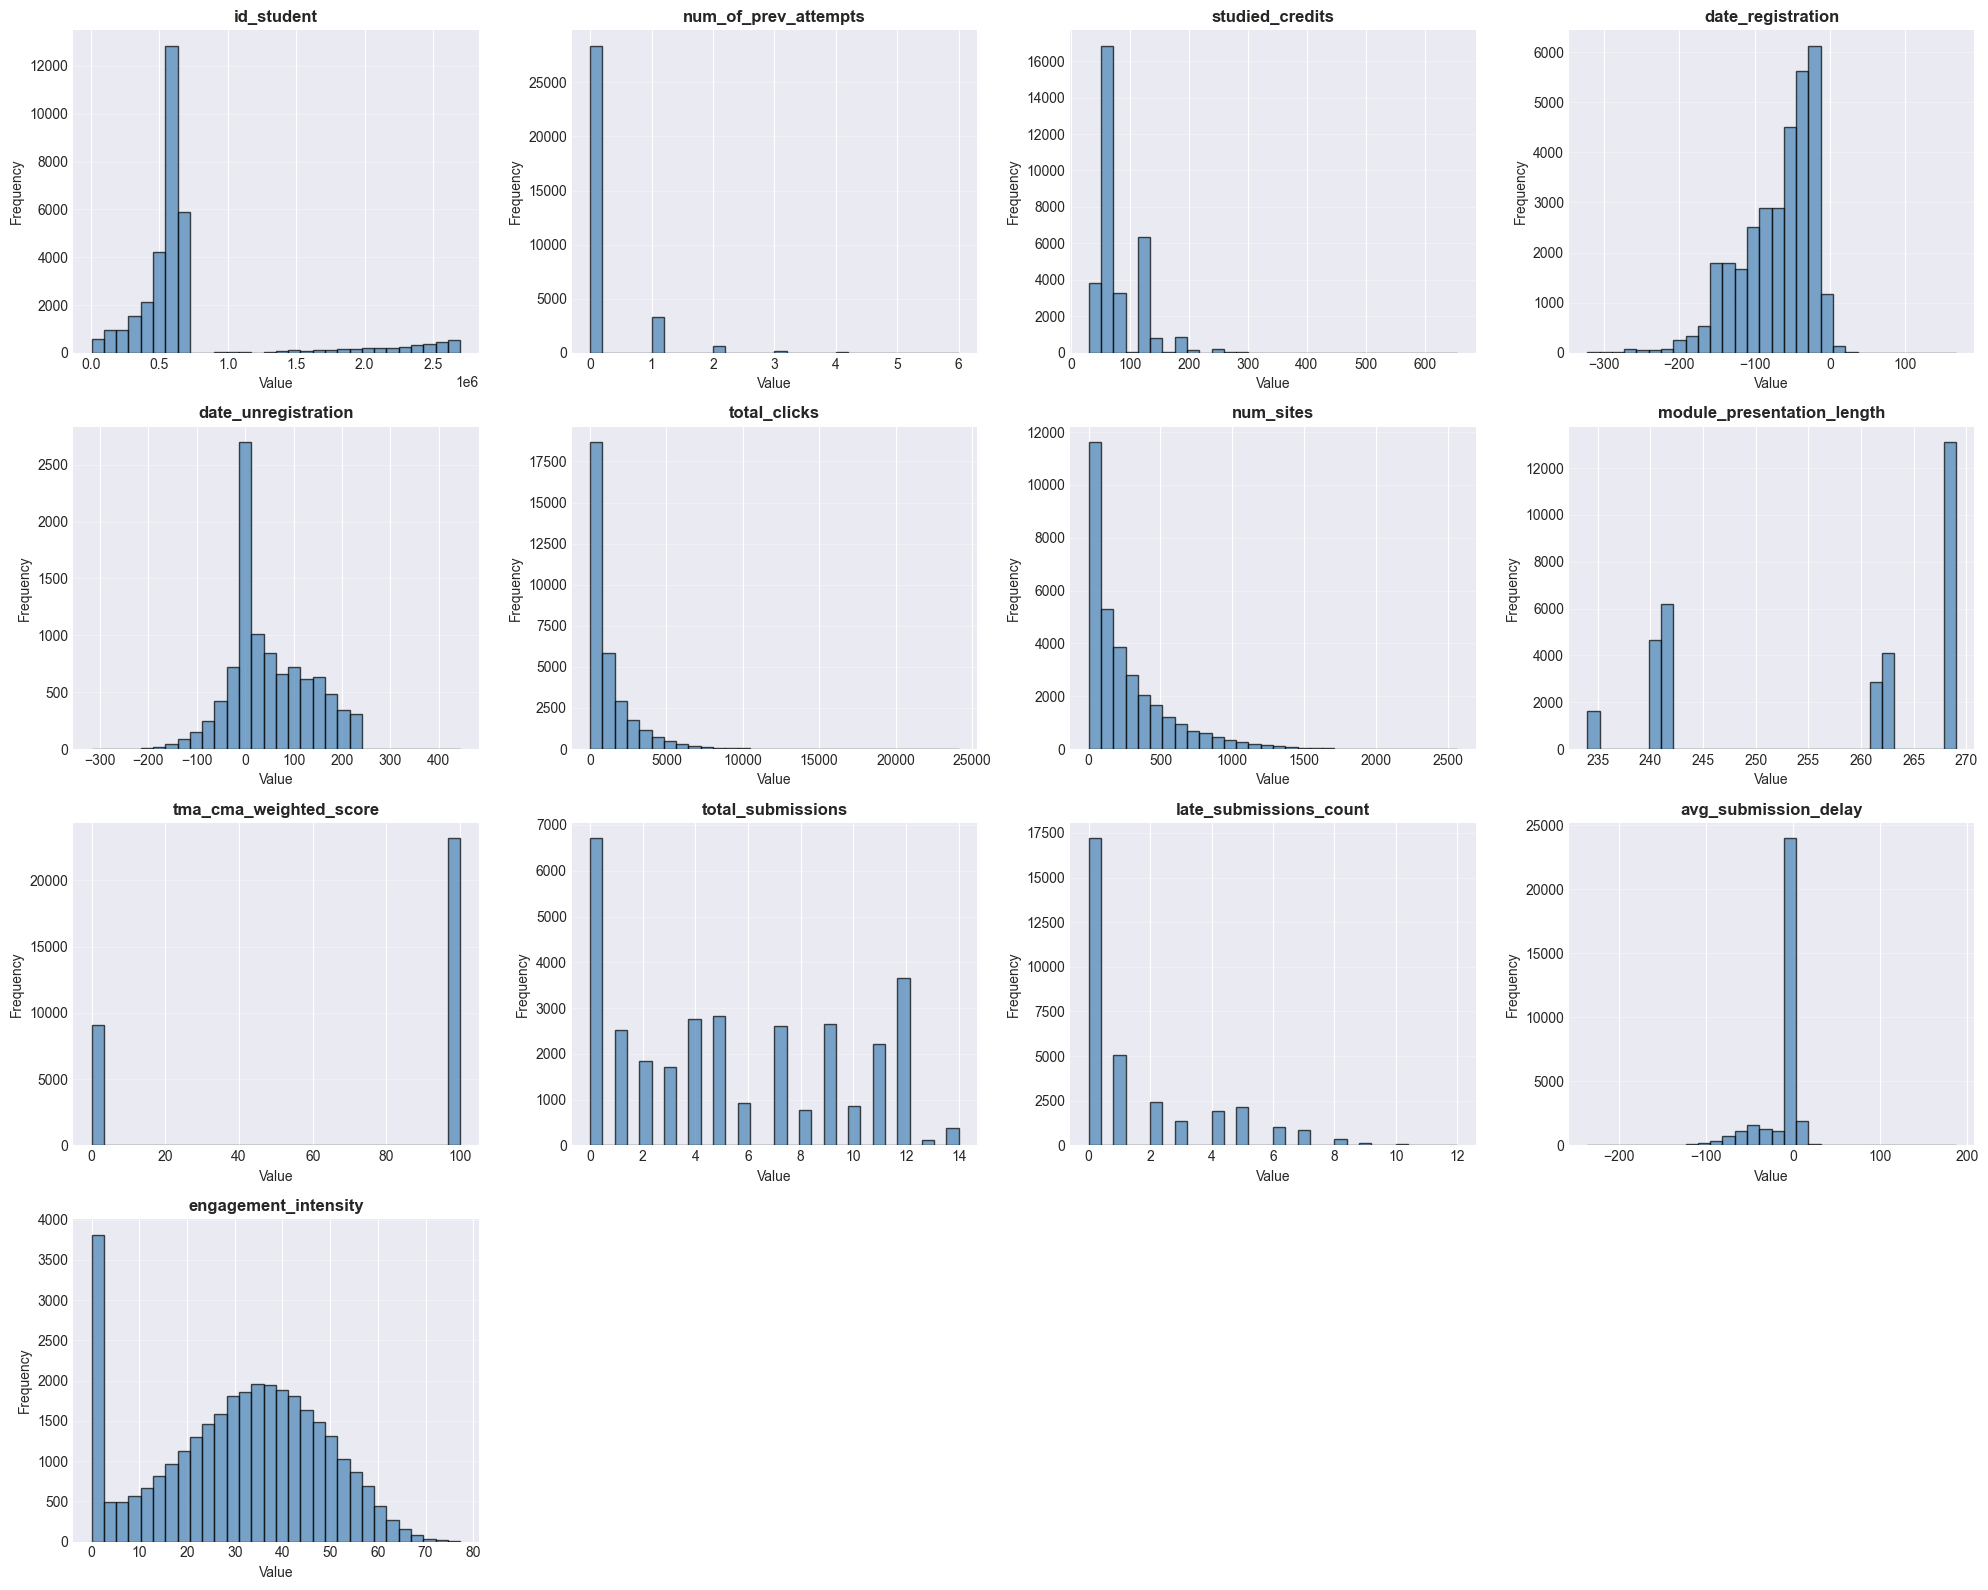

Histograms generated for 13 numerical features


In [74]:
# Create histograms for all numerical features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate grid dimensions
n_features = len(numeric_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes_flat = axes.flatten()

for idx, feature in enumerate(numeric_features):
    axes_flat[idx].hist(df[feature].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes_flat[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes_flat[idx].set_xlabel('Value', fontsize=10)
    axes_flat[idx].set_ylabel('Frequency', fontsize=10)
    axes_flat[idx].grid(axis='y', alpha=0.3)

# Hide empty subplots
for idx in range(n_features, len(axes_flat)):
    fig.delaxes(axes_flat[idx])

plt.tight_layout()
plt.show()

print(f"Histograms generated for {n_features} numerical features")

In [75]:
# Detailed outlier analysis
print("="*80)
print("OUTLIER ANALYSIS FOR SCALING STRATEGY SELECTION")
print("="*80)

for feature in features_to_analyze:
    print(f"\n{feature}:")
    
    # Calculate IQR-based outliers
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers detected: {len(outliers)} ({outlier_pct:.2f}%)")
    print(f"  Skewness: {df[feature].skew():.3f}")
    print(f"  Kurtosis: {df[feature].kurtosis():.3f}")
    
    if outlier_pct > 5:
        print(f"  ⚠ Recommendation: Use RobustScaler (significant outliers)")
    else:
        print(f"  ✓ Recommendation: StandardScaler is acceptable")

OUTLIER ANALYSIS FOR SCALING STRATEGY SELECTION

num_of_prev_attempts:
  Q1: 0.00, Q3: 0.00, IQR: 0.00
  Outlier bounds: [0.00, 0.00]
  Outliers detected: 4165 (12.80%)
  Skewness: 3.804
  Kurtosis: 19.395
  ⚠ Recommendation: Use RobustScaler (significant outliers)

studied_credits:
  Q1: 60.00, Q3: 120.00, IQR: 60.00
  Outlier bounds: [-30.00, 210.00]
  Outliers detected: 348 (1.07%)
  Skewness: 1.879
  Kurtosis: 7.768
  ✓ Recommendation: StandardScaler is acceptable

date_registration:
  Q1: -100.00, Q3: -29.00, IQR: 71.00
  Outlier bounds: [-206.50, 77.50]
  Outliers detected: 339 (1.04%)
  Skewness: -1.008
  Kurtosis: 1.002
  ✓ Recommendation: StandardScaler is acceptable

total_clicks:
  Q1: 144.00, Q3: 1587.00, IQR: 1443.00
  Outlier bounds: [-2020.50, 3751.50]
  Outliers detected: 2501 (7.68%)
  Skewness: 3.027
  Kurtosis: 14.938
  ⚠ Recommendation: Use RobustScaler (significant outliers)

num_sites:
  Q1: 43.00, Q3: 373.00, IQR: 330.00
  Outlier bounds: [-452.00, 868.00]
  Outl

## 4. Categorical Impact Analysis

Analyze how categorical features (highest_education, imd_band) influence final_result outcomes.


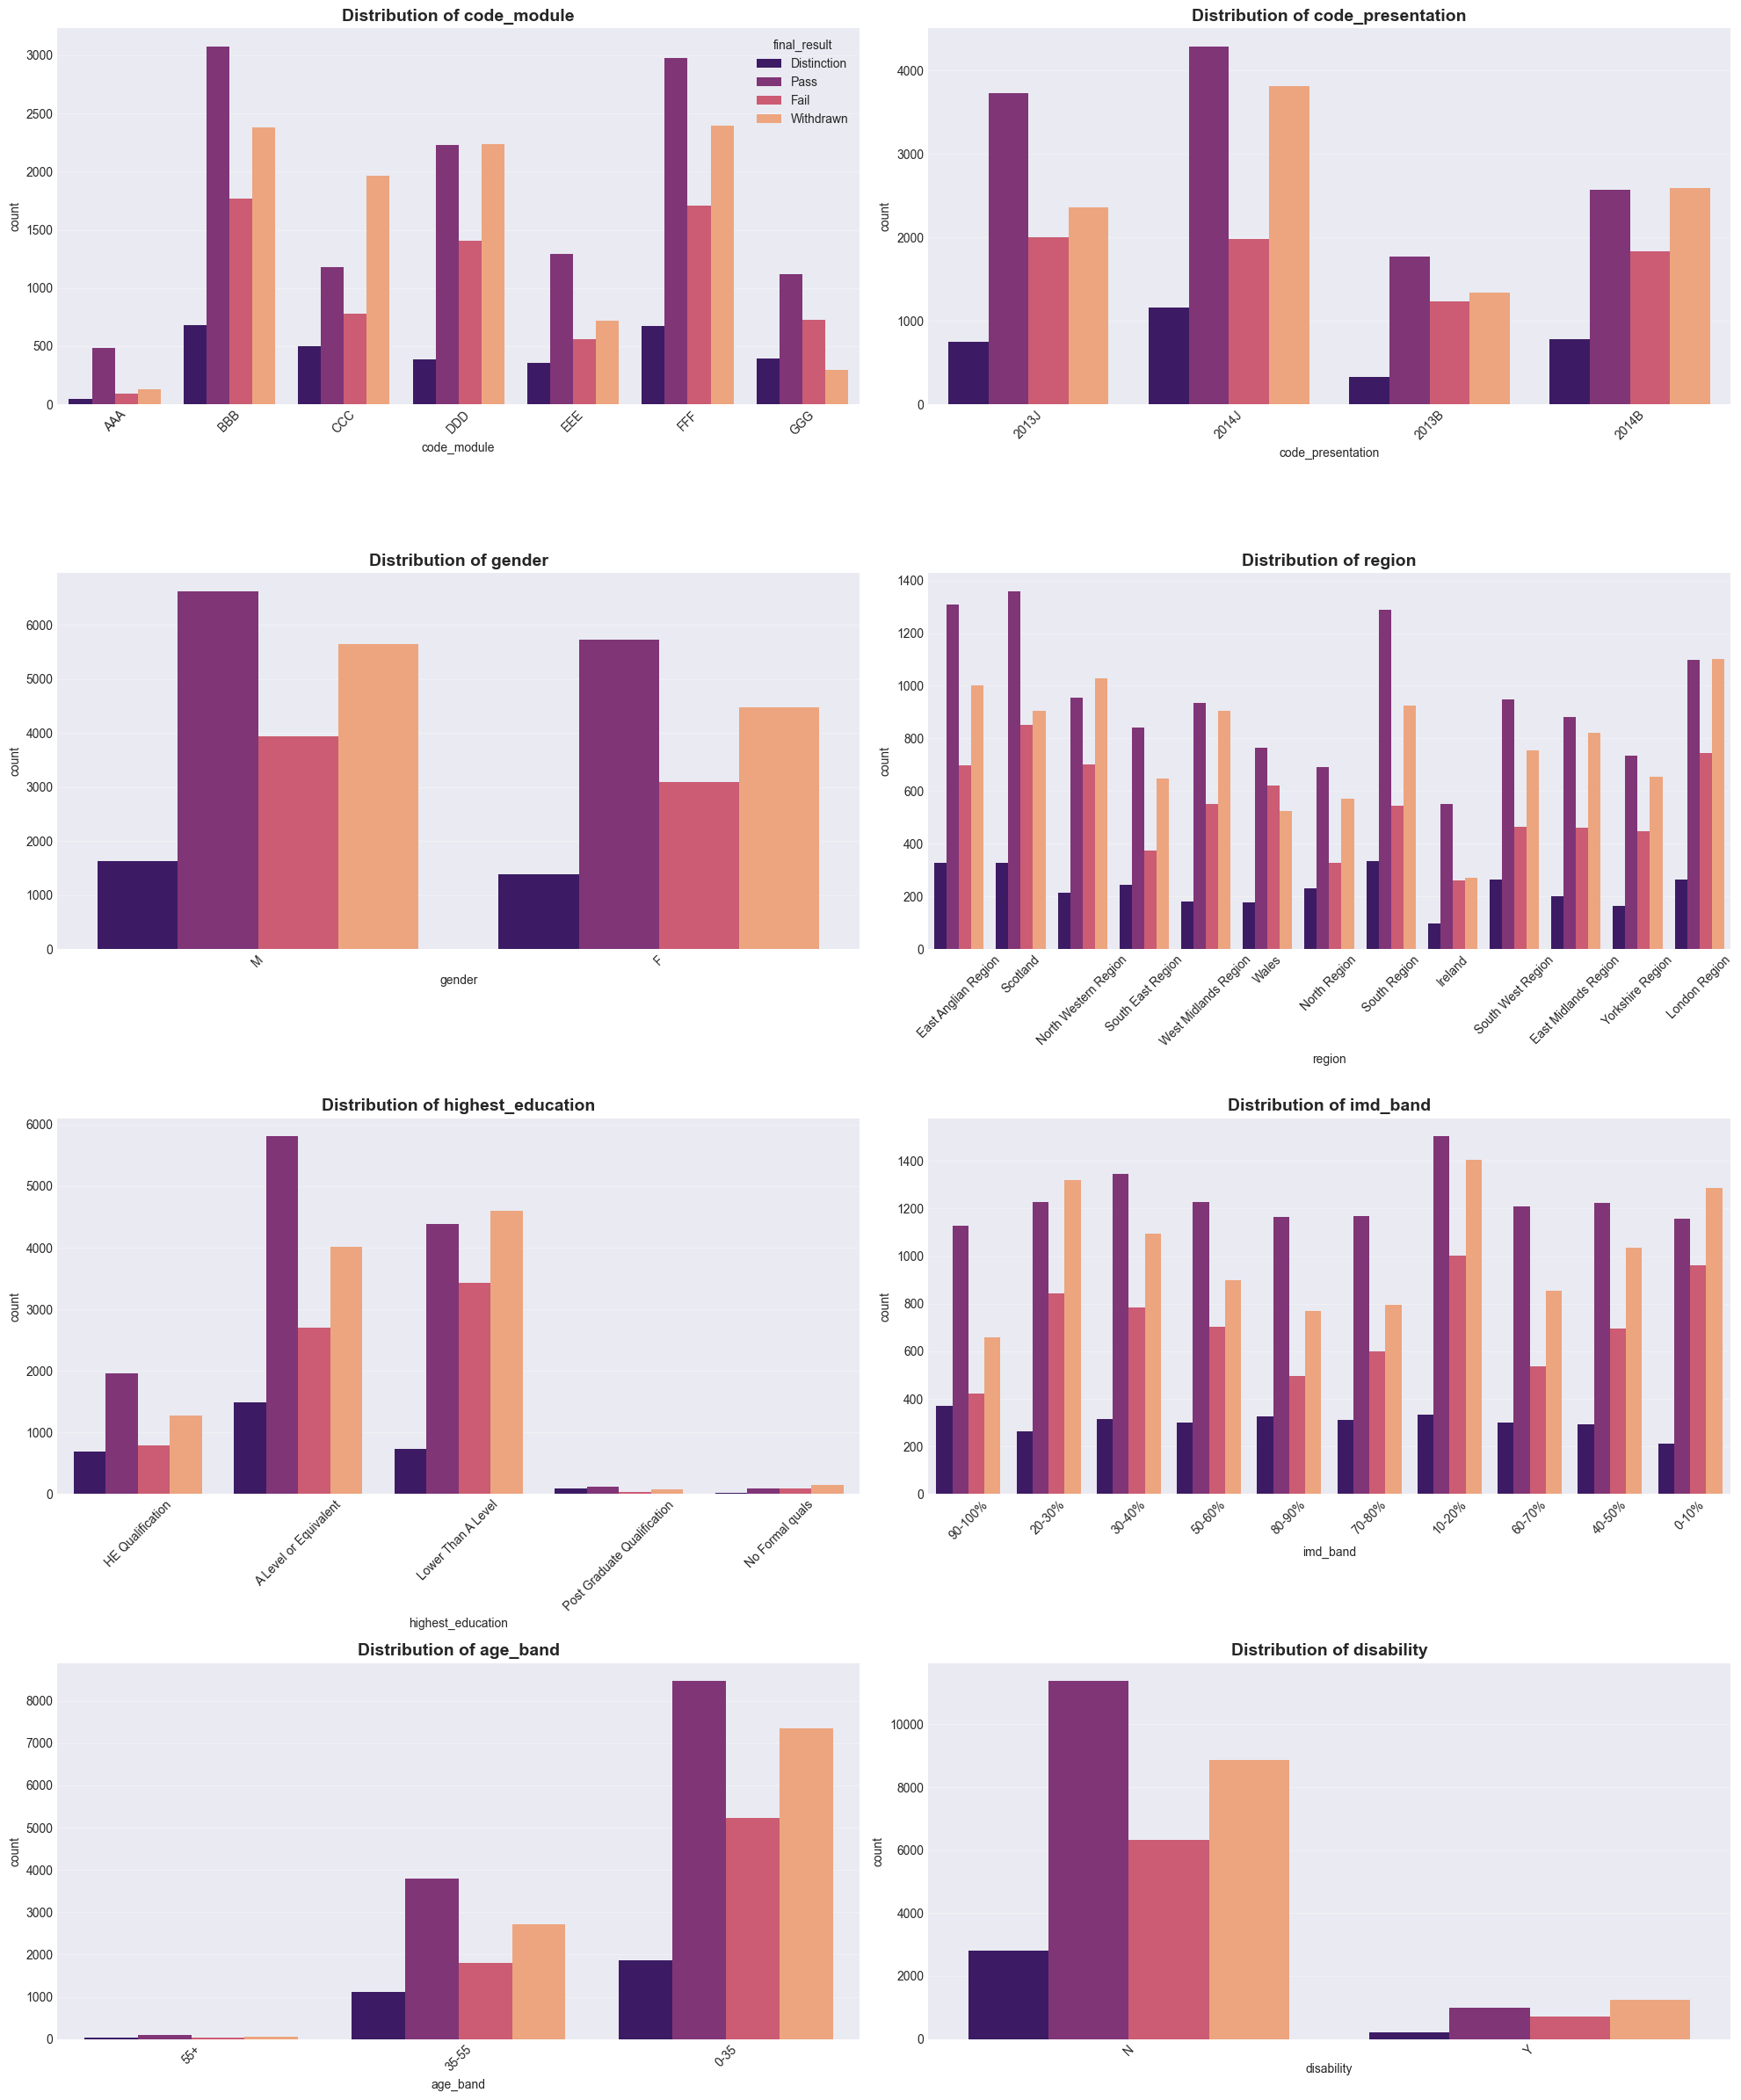

In [76]:
# 1. Filter for categorical columns
categorical_features = [col for col in df if df[col].dtype not in ['int64', 'float64']]

# 2. Set up the grid (4x2 = 8 slots)
fig, axes = plt.subplots(4, 2, figsize=(20, 24))
axes_flat = axes.flatten()

# 3. Use zip to pair features with axes - stops automatically at the end of the shorter list
for feature, ax in zip(categorical_features, axes_flat):
    sns.countplot(
        data=df, 
        x=feature, 
        hue='final_result', 
        hue_order=['Distinction', 'Pass', 'Fail', 'Withdrawn'],
        ax=ax, 
        palette='magma'
    )
    
    ax.set_title(f'Distribution of {feature}', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    # Optional: Legend only on the first plot for a cleaner look
    if ax != axes_flat[0]:
        ax.get_legend().remove()

# 4. Final layout cleanup
plt.tight_layout()
plt.show()

## 5. Target Variable Analysis

Visualize the distribution of final_result to understand class imbalance, which is critical for model selection and evaluation strategy.


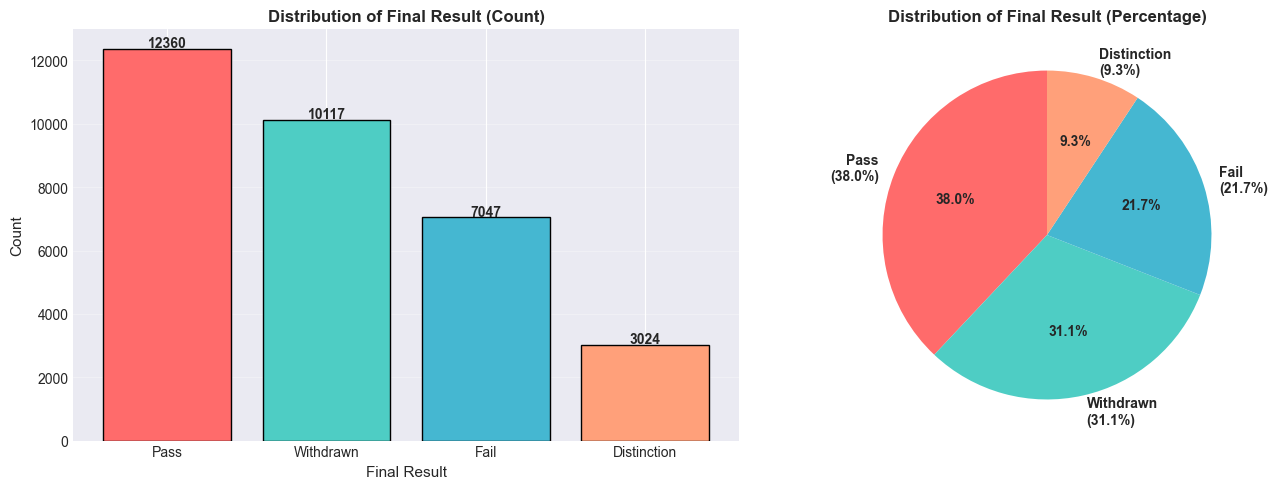

Target distribution plots generated successfully


In [77]:
# Final result distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
result_counts = df['final_result'].value_counts()
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#ffa07a']

axes[0].bar(result_counts.index, result_counts.values, color=colors[:len(result_counts)], edgecolor='black')
axes[0].set_title('Distribution of Final Result (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Final Result', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(result_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
result_pct = (result_counts / len(df)) * 100
axes[1].pie(
    result_counts.values,
    labels=[f"{result}\n({pct:.1f}%)" for result, pct in zip(result_counts.index, result_pct.values)],
    colors=colors[:len(result_counts)],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
axes[1].set_title('Distribution of Final Result (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Target distribution plots generated successfully")

In [78]:
# Detailed target analysis
print("="*80)
print("TARGET VARIABLE ANALYSIS - CLASS IMBALANCE")
print("="*80)

print("\nFinal Result Distribution:")
for result, count in result_counts.items():
    pct = (count / len(df)) * 100
    print(f"  {result}: {count:,} ({pct:.2f}%)")

# Calculate imbalance ratio
max_class = result_counts.max()
min_class = result_counts.min()
imbalance_ratio = max_class / min_class

print(f"\nImbalance Ratio (max/min): {imbalance_ratio:.2f}:1")

if imbalance_ratio > 3:
    print("⚠ HIGH CLASS IMBALANCE DETECTED")
    print("  Recommendation: Consider stratified sampling, class weights, or SMOTE for modeling")
elif imbalance_ratio > 1.5:
    print("⚠ MODERATE CLASS IMBALANCE DETECTED")
    print("  Recommendation: Monitor metrics carefully; use stratified cross-validation")
else:
    print("✓ BALANCED CLASSES")
    print("  Recommendation: Standard training approaches should work well")

TARGET VARIABLE ANALYSIS - CLASS IMBALANCE

Final Result Distribution:
  Pass: 12,360 (37.97%)
  Withdrawn: 10,117 (31.08%)
  Fail: 7,047 (21.65%)
  Distinction: 3,024 (9.29%)

Imbalance Ratio (max/min): 4.09:1
⚠ HIGH CLASS IMBALANCE DETECTED
  Recommendation: Consider stratified sampling, class weights, or SMOTE for modeling


## Summary & Recommendations for Modeling

Key findings from EDA analysis


In [79]:
print("="*80)
print("EDA SUMMARY & MODELING RECOMMENDATIONS")
print("="*80)

print("\n1. DATA QUALITY:")
print(f"   - Total records: {df.shape[0]:,}")
print(f"   - Total features: {df.shape[1]}")
print(f"   - Missing values: {df.isnull().sum().sum()}")

print("\n2. SCALING STRATEGY:")
outlier_features = []
for feature in features_to_analyze:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)]
    if (len(outliers) / len(df)) > 0.05:
        outlier_features.append(feature)

if outlier_features:
    print(f"   ⚠ Use RobustScaler for features with outliers: {outlier_features}")
else:
    print(f"   ✓ StandardScaler acceptable for all numeric features")

print("\n3. CLASS BALANCE:")
if imbalance_ratio > 3:
    print(f"   ⚠ HIGH IMBALANCE ({imbalance_ratio:.1f}:1) - Use stratified sampling")
elif imbalance_ratio > 1.5:
    print(f"   ⚠ MODERATE IMBALANCE ({imbalance_ratio:.1f}:1) - Use class weights")
else:
    print(f"   ✓ Balanced classes ({imbalance_ratio:.1f}:1)")

print("\n4. FEATURE CORRELATION:")
strong_corr = final_result_corr[abs(final_result_corr) > 0.3].drop('final_result')
print(f"   Strong predictors of final_result (|r| > 0.3): {strong_corr.index.tolist()}")

print("\n5. CATEGORICAL INSIGHTS:")
print(f"   - Education level shows impact on success rates")
print(f"   - IMD band (socioeconomic factor) affects outcomes")
print(f"   - Consider interaction features between these categorical variables")

print("\n6. MODEL SELECTION SUGGESTIONS:")
print("   - Use stratified k-fold cross-validation")
print("   - Consider gradient boosting (handles non-linear relationships, outliers)")
print("   - Evaluate on F1 or weighted precision/recall (due to class imbalance)")
print("   - Include feature engineering: interaction terms, polynomial features")
print("\n" + "="*80)

EDA SUMMARY & MODELING RECOMMENDATIONS

1. DATA QUALITY:
   - Total records: 32,548
   - Total features: 22
   - Missing values: 22515

2. SCALING STRATEGY:
   ⚠ Use RobustScaler for features with outliers: ['num_of_prev_attempts', 'total_clicks', 'num_sites', 'late_submissions_count', 'avg_submission_delay']

3. CLASS BALANCE:
   ⚠ HIGH IMBALANCE (4.1:1) - Use stratified sampling

4. FEATURE CORRELATION:
   Strong predictors of final_result (|r| > 0.3): ['total_submissions', 'engagement_intensity', 'num_sites', 'total_clicks', 'tma_cma_weighted_score', 'avg_submission_delay']

5. CATEGORICAL INSIGHTS:
   - Education level shows impact on success rates
   - IMD band (socioeconomic factor) affects outcomes
   - Consider interaction features between these categorical variables

6. MODEL SELECTION SUGGESTIONS:
   - Use stratified k-fold cross-validation
   - Consider gradient boosting (handles non-linear relationships, outliers)
   - Evaluate on F1 or weighted precision/recall (due to cla